In [1]:
import gensim
gensim.__version__

'4.4.0'

In [2]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/affx/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## 1. GloVE
- 카운트 기반과 예측 기반을 모두 사용하는 방법론

### 1.1 기존 방법론에 대한 비판
- LSA: 각 단어의 빈도수 통계를 입력으로 받아 차원축소(Truncated SVD)를 통해 벡터화
    - 의미 유추(Analogy Task) 작업에서 성능이 떨어짐
- Word2Vec: 실제값과 예측값에 대한 오차를 손실 함수를 통해 줄여나가며 학습하하여 벡터화
    - 윈도우 크기 내에서만 단어간의 관계를 고려

### 1.2 대안: 윈도우 기반 동시 등장 확률로 학습하여 벡터화
- 윈도우 기반 동시 등장 행렬 $M_{[i, k]}$: i 단어의 윈도우 내에서 k 단어가 등장한 횟수
- 동시 등장 확률 $P(k|i)$: i가 등장했을 때 k가 등장할 조건부 확률

|동시 등장 확률 (예제)|k=solid|k=gas|k=water|k=fasion|
|--|--|--|--|--|
|P(k l ice)|0.00019|0.000066|0.003|0.000017|
|P(k l steam)|0.000022|0.00078|0.0022|0.000018|
|P(k l ice) / P(k l steam)|8.9|0.085|1.36|0.96|

### 1.3 목표
- 임베딩 된 중심 단어와 주변 단어 벡터의 내적이 전체 코퍼스에서의 동시 등장 확률이 되도록 만드는 것
  - $X$ : 동시 등장 행렬(Co-occurrence Matrix)
  - $X_{ij}$ : 중심 단어 i가 등장했을 때 윈도우 내 주변 단어 j가 등장하는 횟수
  - $X_i = \sum_j X_{ij}$ : 동시 등장 행렬에서 i행의 값을 모두 더한 값
  - $P_{ik} = P(k|i) = \frac{X_{ik}}{X_i}$ : 중심 단어 i가 등장했을 때 윈도우 내 주변 단어 k가 등장할 확률
  - $w_i$ : 중심 단어 i의 임베딩 벡터
  - $\tilde{w_k}$ : 주변 단어 k의 임베딩 벡터

$$w_{i} \cdot \tilde{w_{k}} \approx \ln{P(k\ |\ i)} = \ln{P_{ik}}$$

### 1.4 손실 함수
- 기본형
$$
\begin{align*}
J(w_m​,\tilde{w_n}​,b_m​,\tilde{b_n​}) &= \sum_{m, n=1}^{V}\ (w_{m}^{T}\tilde{w_{n}} + b_{m} + \tilde{b_{n}} - \ln X_{mn})^{2} \\
\text{where } V &= \text{Vocabulary size}
\end{align*}
$$
- 희소 벡터를 보정하기 위한 가중치
$$f(x) = \min(1, (\frac{x}{x_{\max}})^\frac{3}{4})$$
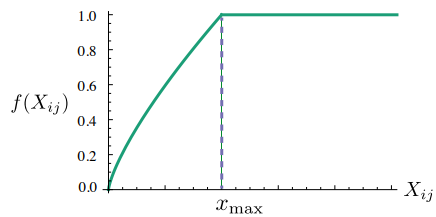

In [3]:
import urllib.request
import zipfile
from lxml import etree
import re
from nltk.tokenize import word_tokenize, sent_tokenize

In [6]:
# 데이터 다운로드
urllib.request.urlretrieve("https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/main/09.%20Word%20Embedding/dataset/ted_en-20160408.xml", filename="data/ted_en-20160408.xml")

('data/ted_en-20160408.xml', <http.client.HTTPMessage at 0x785485d62750>)

In [7]:
targetXML = open('data/ted_en-20160408.xml', 'r', encoding='UTF8')
target_text = etree.parse(targetXML)

# xml 파일로부터 <content>와 </content> 사이의 내용만 가져온다.
parse_text = '\n'.join(target_text.xpath('//content/text()'))

# 정규 표현식의 sub 모듈을 통해 content 중간에 등장하는 (Audio), (Laughter) 등의 배경음 부분을 제거.
# 해당 코드는 괄호로 구성된 내용을 제거.
content_text = re.sub(r'\([^)]*\)', '', parse_text)

# 입력 코퍼스에 대해서 NLTK를 이용하여 문장 토큰화를 수행.
sent_text = sent_tokenize(content_text)

# 각 문장에 대해서 구두점을 제거하고, 대문자를 소문자로 변환.
normalized_text = []
for string in sent_text:
     tokens = re.sub(r"[^a-z0-9]+", " ", string.lower())
     normalized_text.append(tokens)

# 각 문장에 대해서 NLTK를 이용하여 단어 토큰화를 수행.
result = [word_tokenize(sentence) for sentence in normalized_text]

In [8]:
print('총 샘플의 개수 : {}'.format(len(result)))

총 샘플의 개수 : 273424


In [9]:
# 샘플 3개만 출력
for line in result[:3]:
    print(line)

['here', 'are', 'two', 'reasons', 'companies', 'fail', 'they', 'only', 'do', 'more', 'of', 'the', 'same', 'or', 'they', 'only', 'do', 'what', 's', 'new']
['to', 'me', 'the', 'real', 'real', 'solution', 'to', 'quality', 'growth', 'is', 'figuring', 'out', 'the', 'balance', 'between', 'two', 'activities', 'exploration', 'and', 'exploitation']
['both', 'are', 'necessary', 'but', 'it', 'can', 'be', 'too', 'much', 'of', 'a', 'good', 'thing']


In [10]:
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

In [11]:
model = Word2Vec(sentences=result, vector_size=100, window=5, min_count=5, workers=4, sg=0)

여기서 Word2Vec의 인자는 다음과 같습니다.  

* size = 워드 벡터의 특징 값. 즉, 임베딩 된 벡터의 차원.
* window = 컨텍스트 윈도우 크기
* min_count = 단어 최소 빈도 수 제한 (빈도가 적은 단어들은 학습하지 않는다.)
* workers = 학습을 위한 프로세스 수
* sg = 0은 CBOW, 1은 Skip-gram.

In [12]:
model_result = model.wv.most_similar("man")
print(model_result)

[('woman', 0.8366532921791077), ('guy', 0.8165754079818726), ('lady', 0.7823721766471863), ('boy', 0.7351094484329224), ('girl', 0.7196888327598572), ('soldier', 0.7076788544654846), ('gentleman', 0.7019831538200378), ('poet', 0.6764270067214966), ('friend', 0.664405107498169), ('kid', 0.6617459058761597)]


In [ ]:
model.wv.save_word2vec_format('models/eng_w2v_1205') # 모델 저장
loaded_model = KeyedVectors.load_word2vec_format("models/eng_w2v_1205") # 모델 로드

In [14]:
model_result = loaded_model.most_similar("man")
print(model_result)

[('woman', 0.8366532921791077), ('guy', 0.8165754079818726), ('lady', 0.7823721766471863), ('boy', 0.7351094484329224), ('girl', 0.7196888327598572), ('soldier', 0.7076788544654846), ('gentleman', 0.7019831538200378), ('poet', 0.6764270067214966), ('friend', 0.664405107498169), ('kid', 0.6617459058761597)]


## 2. 패스트텍스트(FastText)
- 하나의 단어 안에도 여러 단어들이 존재하는 것으로 간주
- 각 단어는 글자 단위 n-gram의 구성(내부 단어)으로 취급
- 내부 단어에 대해 W2V을 수행하고, 그 벡터의 총합으로 단어의 벡터 설정

### 2.1 장점
- 내부 단어(Subword)를 통해 모르는 단어(Out of Vocabulary)와 다른 단어의 벡터 연산 가능
- 빈도 수가 적었던 단어(Rare Word)에 대한 대응 가능

In [15]:
model.wv.most_similar("electrofishing")

KeyError: "Key 'electrofishing' not present in vocabulary"

In [16]:
from gensim.models import FastText

model = FastText(result, vector_size=100, window=5, min_count=5, workers=4, sg=1)

In [17]:
model.wv.most_similar("electrofishing")

[('electrolux', 0.8714218139648438),
 ('electrolyte', 0.864896297454834),
 ('electro', 0.8548117280006409),
 ('electroencephalogram', 0.8485689759254456),
 ('electroshock', 0.8476819396018982),
 ('electrogram', 0.8327114582061768),
 ('electrochemical', 0.8260906934738159),
 ('electron', 0.8194519281387329),
 ('electronic', 0.8178626894950867),
 ('airbus', 0.8168861269950867)]